Starting Variational EM optimization for 1000 epochs with batch size 50...
Epoch 10/1000, Final Batch ELBO: -250.1585
Epoch 20/1000, Final Batch ELBO: -133.7701
Epoch 30/1000, Final Batch ELBO: -138.5499
Epoch 40/1000, Final Batch ELBO: -119.3727
Epoch 50/1000, Final Batch ELBO: -62.8927
Epoch 60/1000, Final Batch ELBO: -21.7153
Epoch 70/1000, Final Batch ELBO: -24.4345
Epoch 80/1000, Final Batch ELBO: -42.1160
Epoch 90/1000, Final Batch ELBO: -90.3095
Epoch 100/1000, Final Batch ELBO: -0.3628
Epoch 110/1000, Final Batch ELBO: -0.1977
Epoch 120/1000, Final Batch ELBO: 53.8296
Epoch 130/1000, Final Batch ELBO: -19.6555
Epoch 140/1000, Final Batch ELBO: -29.8566
Epoch 150/1000, Final Batch ELBO: -99.5642
Epoch 160/1000, Final Batch ELBO: -48.8343
Epoch 170/1000, Final Batch ELBO: 16.4821
Epoch 180/1000, Final Batch ELBO: -0.6067
Epoch 190/1000, Final Batch ELBO: 13.0297
Epoch 200/1000, Final Batch ELBO: -36.8093
Epoch 210/1000, Final Batch ELBO: -54.5333
Epoch 220/1000, Final Batch ELBO:

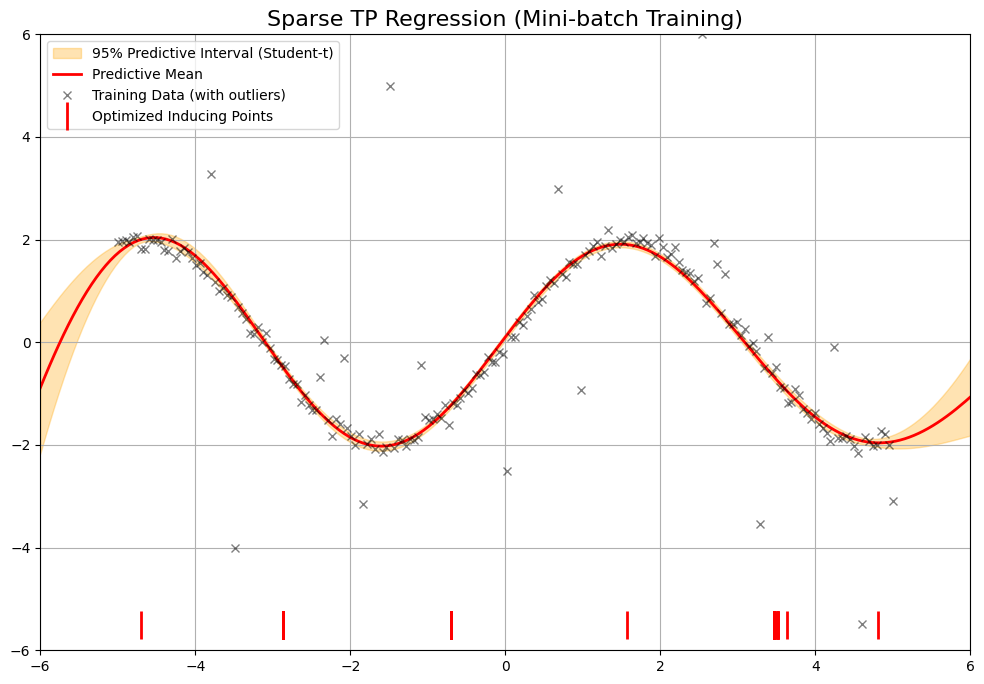

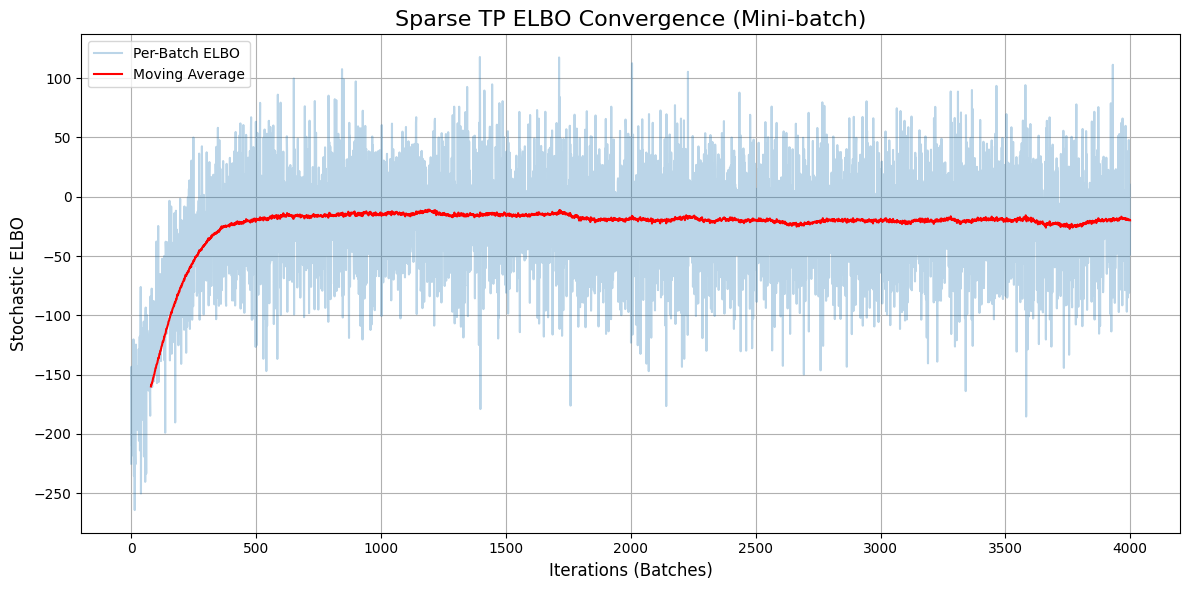

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTMiniBatch:
    """
    Implementation of Variational EM for Student-t Process Regression with Mini-batching.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points
              using a stochastic estimate of the ELBO.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Full training inputs, shape (N, D).
            y (torch.Tensor): Full training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X_full = X # Keep full data for reference (e.g., initialization)
        self.y_full = y.view(-1, 1) # Keep full data for reference
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence from the full dataset ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize GLOBAL Variational Parameters (updated across batches) ---
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        # LOCAL variational parameters (alpha_lambda, beta_lambda) are computed on-the-fly for each batch

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    # === E-Step Methods (now operate on a batch) ===
    def _update_q_lambda(self, y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u # Shape: (B, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1) # Shape: (B, 1)

        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        alpha_lambda_batch = params['nu_epsilon'] / 2.0 + 0.5
        beta_lambda_batch = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
        return alpha_lambda_batch, beta_lambda_batch

    def _update_q_r(self, params, L_ZZ):
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = alpha_lambda_batch.squeeze() / beta_lambda_batch.squeeze()
        c = expected_lambda / params['sigma_sq']

        B = (K_ZX_batch * c) @ K_XZ_batch
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)

        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        y_term = K_ZX_batch @ (y_batch.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter):
        # Kernels relevant to the batch
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(X_batch.shape[0])

        # Local vars for lambda are re-calculated each time
        alpha_lambda_batch, beta_lambda_batch = None, None

        for _ in range(cavi_max_iter):
            alpha_lambda_batch, beta_lambda_batch = self._update_q_lambda(y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch)
            self._update_q_r(params, L_ZZ) # Depends on global S_u, m_u
            self._update_q_u(y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, K_XZ_batch, K_ZX_batch) # Uses batch data

        return alpha_lambda_batch, beta_lambda_batch


    def _e_step(self, X_batch, y_batch, cavi_max_iter=10):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # Perform CAVI for the current batch, updating global (m_u, S_u, etc.) and getting local params
            alpha_lambda_batch, beta_lambda_batch = self._cavi_step(X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter)

        return alpha_lambda_batch, beta_lambda_batch


    # === M-Step Methods (now operate on a batch) ===
    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        optimizer.zero_grad()
        # Pass batch-specific variational parameters to ELBO calculation
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
    
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        B = X_batch.shape[0] # Batch size
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(B)
        
        # --- 1. Expected Log-Likelihood (Data-dependent term) ---
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        log_lik = log_lik_batch * (self.N / B)

        # --- 2. KL Divergences ---
        # KL[q(r) || p(r)] (Global term, NOT scaled)
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)] (Global term, NOT scaled)
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        L_S = torch.linalg.cholesky(self.S_u)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * expected_u_quadratic - self.M).squeeze()
        
        # KL[q(lambda) || p(lambda)] (Data-dependent term)
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        kl_lambda = kl_lambda_batch * (self.N / B)

        return log_lik - kl_u - kl_r - kl_lambda

    def fit(self, epochs=100, batch_size=64, cavi_max_iter=5, lr=0.01):
        """Runs the full Variational EM algorithm using mini-batches."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        # Create DataLoader for mini-batching
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):

                # print(f"Processing batch {i+1}/{len(dataloader)} in epoch {epoch+1}...")

                # E-Step: Update global variational params and get local ones for the batch
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, cavi_max_iter=cavi_max_iter)
                
                # M-Step: Update hyperparameters using the stochastic ELBO from the batch
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test. (No changes needed here)
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=1000, batch_size=50, cavi_max_iter=20, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [29]:
# data loader の挙動を理解したい

X_temp = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1) # Example data
dataset = TensorDataset(X_temp)
dataloader = DataLoader(dataset, batch_size=5, shuffle=True)

for epoch in range(2):  # Run for 2 epochs to see shuffling
    print(f"Epoch {epoch + 1}")
    for X_batch in dataloader:
        print(X_batch[0].flatten())  # Should print torch.Size


Epoch 1
tensor([5, 7, 0, 2, 6])
tensor([1, 3, 9, 8, 4])
Epoch 2
tensor([4, 5, 3, 9, 8])
tensor([1, 0, 7, 6, 2])


In [27]:
X_temp

tensor([[-5.0000],
        [-3.8889],
        [-2.7778],
        [-1.6667],
        [-0.5556],
        [ 0.5556],
        [ 1.6667],
        [ 2.7778],
        [ 3.8889],
        [ 5.0000]])

Starting optimization...
Iteration 50/100, Loss: -614.9462
Iteration 100/100, Loss: -645.7095

Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 1.898
Kernel Variance: 2.890
Likelihood Sigma: 0.337
Prior DoF (nu_f): 0.866
Likelihood DoF (nu_e): 1.562


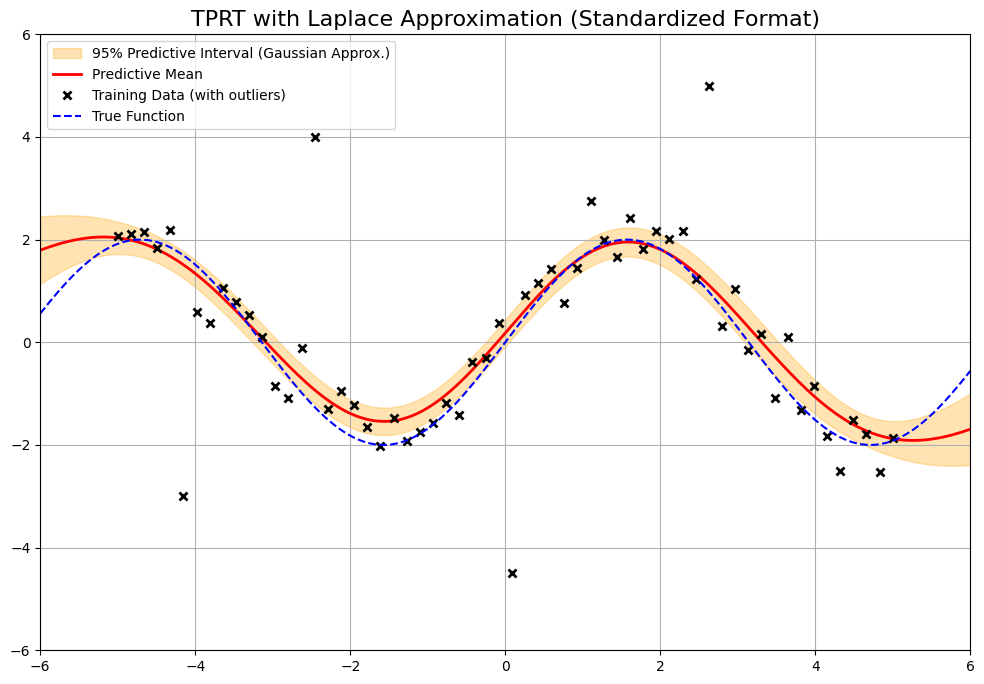

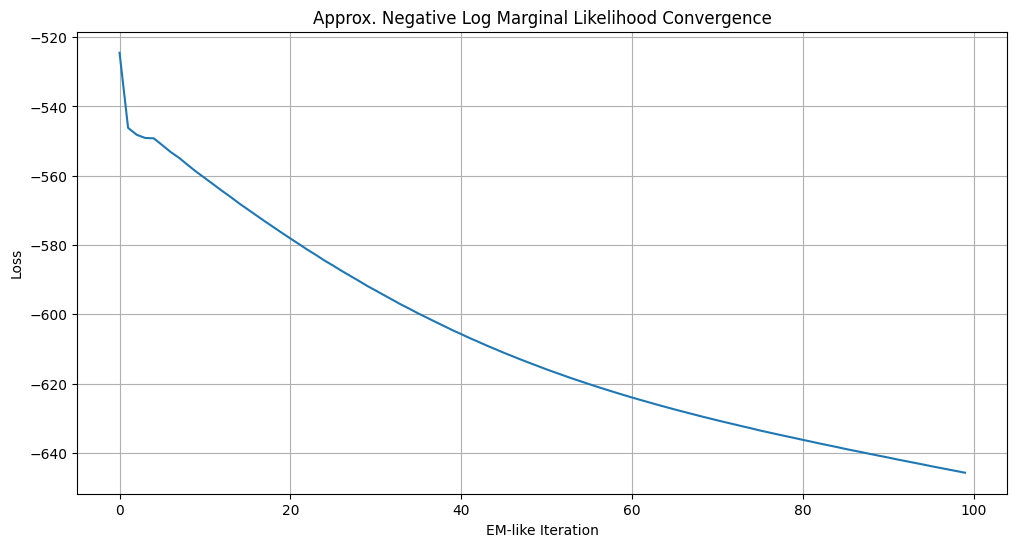

🚀 Starting training with method: UB


Epoch 2800 | -ELBO: 36.03 | ν: 2.13 | ν̃: 202.13 | ν_lik: 2.01: 100%|██████████| 3000/3000 [00:13<00:00, 226.33it/s] 


✓ Training complete for method: UB
🚀 Starting training with method: MC


Epoch 2800 | -ELBO: -181.17 | ν: 7.82 | ν̃: 207.82 | ν_lik: 2.02: 100%|██████████| 3000/3000 [00:18<00:00, 162.84it/s]


✓ Training complete for method: MC


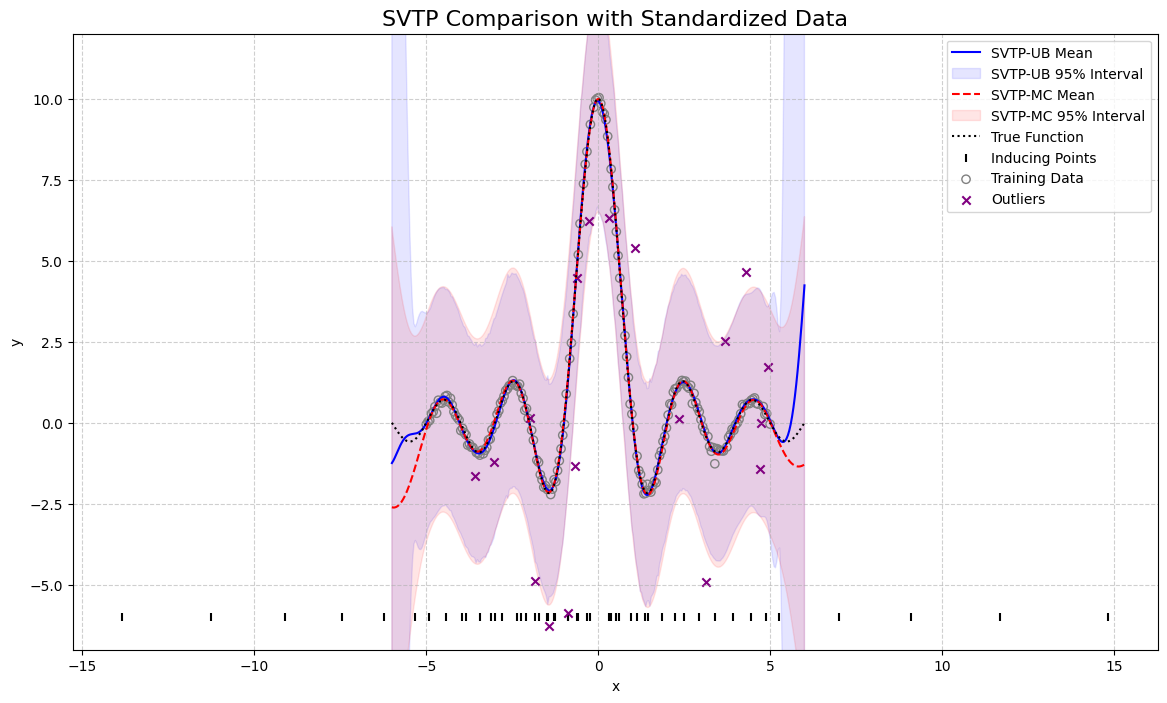

In [40]:
import torch
import torch.nn as nn
from torch.distributions import StudentT, Gamma
import math
import copy
import matplotlib.pyplot as plt
import tqdm

# # For reproducibility
# torch.manual_seed(1234)
torch.set_default_dtype(torch.float64)

# ═══ 1. Helper Function for Student-t Log-PDF ══════════════════════

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    diff = x - mu.unsqueeze(-1)
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2


# ═══ 2. SVTP Model Definition ══════════════════════════════════════

class SparseTPRTMiniBatch_Xu(nn.Module):
    def __init__(self, X, y, Z_init):
        super().__init__()
        self.register_buffer('X', X)
        self.register_buffer('y', y)
        self.N, self.D = X.shape[0], X.shape[1] if len(X.shape) > 1 else 1
        self.M = Z_init.shape[0]

        # --- Trainable Parameters ---
        self.Z = nn.Parameter(Z_init)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_sigma_n = nn.Parameter(torch.log(torch.tensor(0.1)))
        self.log_nu_lik_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.log_nu_prior_minus_2 = nn.Parameter(torch.log(torch.tensor(3.0 - 2.0)))
        self.mu_q = nn.Parameter(torch.zeros(self.M))
        self.S_chol_q = nn.Parameter(torch.eye(self.M))
        
        # REMOVED: self.log_nu_q_minus_2 is no longer a free parameter.

    def _get_params(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_prior = torch.exp(self.log_nu_prior_minus_2) + 2.0
        
        # MODIFIED: nu_q is now determined by nu_prior and N, per the paper's finding.
        nu_q = nu_prior + self.N
        
        nu_lik = torch.exp(self.log_nu_lik_minus_2) + 2.0
        sigma_n = torch.exp(self.log_sigma_n)
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        return nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance

    def kernel(self, A, B, variance, lengthscale):
        sq_dist = torch.cdist(A.view(-1, self.D), B.view(-1, self.D), p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    # def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
    #     if method == 'MC':
    #         u_samples = self.sample_q_u(nu_q, num_samples=10)
    #         log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
    #         log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
    #         return torch.mean(log_q_u - log_p_u)
        
    #     elif method == 'UB':
    #         # --- Debugging Helper ---
    #         def check(tensor, name):
    #             if torch.isnan(tensor).any() or torch.isinf(tensor).any():
    #                 print(f"DEBUG: Problem detected in '{name}'. Value: {tensor.item()}")
    #                 # Return a dummy value to propagate the nan and stop the backward pass
    #                 return True
    #             return False

    #         # --- Calculation with Checks ---
    #         try:
    #             K_mm_inv = torch.inverse(K_mm)
    #             if check(K_mm_inv.sum(), 'K_mm_inv'): return torch.tensor(float('nan'))
    #         except torch.linalg.LinAlgError:
    #             print("DEBUG: K_mm is singular and cannot be inverted.")
    #             return torch.tensor(float('nan'))

    #         l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
    #         if check(l1, 'l1'): return torch.tensor(float('nan'))

    #         tr_term = torch.trace(K_mm_inv @ S_q)
    #         if check(tr_term, 'tr_term'): return torch.tensor(float('nan'))

    #         mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
    #         if check(mean_term, 'mean_term'): return torch.tensor(float('nan'))
            
    #         # Specifically check the argument to the log, a common source of NaNs
    #         l2_star_arg = 1 + (tr_term + mean_term) / (nu_prior - 2)
    #         if check(l2_star_arg, 'Argument to log for l2_star'): return torch.tensor(float('nan'))
    #         if l2_star_arg <= 0:
    #             print(f"DEBUG: Non-positive argument for log in l2_star. Value: {l2_star_arg.item()}")
    #             return torch.tensor(float('nan'))
            
    #         l2_star = torch.log(l2_star_arg)
    #         if check(l2_star, 'l2_star'): return torch.tensor(float('nan'))

    #         logdet_S = 2 * torch.sum(torch.log(torch.diag(self.S_chol_q)))
    #         if check(logdet_S, 'logdet_S'): return torch.tensor(float('nan'))

    #         sign, logdet_K = torch.linalg.slogdet(K_mm)
    #         if sign.item() <= 0: 
    #             print(f"DEBUG: K_mm matrix is not positive definite. Sign of logdet: {sign.item()}")
    #             return torch.tensor(float('inf'))
    #         if check(logdet_K, 'logdet_K'): return torch.tensor(float('nan'))
            
    #         log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
    #         if check(log_nu_diff, 'log_nu_diff'): return torch.tensor(float('nan'))
            
    #         C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
    #         if check(C, 'C'): return torch.tensor(float('nan'))

    #         kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
    #         if check(kl_approx, 'kl_approx (final)'): return torch.tensor(float('nan'))
            
    #         return kl_approx

    def kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB'):
        """Calculates the KL divergence term KL(q(u) || p(u))."""
        if method == 'MC':
            u_samples = self.sample_q_u(nu_q, num_samples=10)
            log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
            log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X.device), K_mm, nu_prior)
            return torch.mean(log_q_u - log_p_u)
        
        elif method == 'UB':
            K_mm_inv = torch.inverse(K_mm)
            
            # L1 term
            l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
            
            # L2* term
            tr_term = torch.trace(K_mm_inv @ S_q)
            mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
            l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
            
            # --- CORRECTED LOG-DETERMINANT CALCULATION ---
            # Calculate logdet from the guaranteed positive-definite S_q matrix, not the raw parameter
            sign_S, logdet_S = torch.linalg.slogdet(S_q)
            if sign_S.item() <= 0: return float('inf')

            sign_K, logdet_K = torch.linalg.slogdet(K_mm)
            if sign_K.item() <= 0: return float('inf')
            
            # The term (nu_q - 2) must be handled carefully as nu_q can be large
            log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
            
            C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
            kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
            return kl_approx

    def expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples=1):
        u_samples = self.sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def elbo(self, X_batch, y_batch, kl_method='UB', num_samples=1):
        nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
        K_nm = self.kernel(X_batch, self.Z, variance, lengthscale)
        K_mm_inv = torch.inverse(K_mm)

        kl = self.kl_divergence(K_mm, S_q, nu_prior, nu_q, method=kl_method)
        exp_log_lik = self.expected_log_likelihood(X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def fit(self, epochs, optimizer, kl_method='UB', batch_size=128, num_samples=1):
        data_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(self.X, self.y), batch_size=batch_size, shuffle=True)
        print(f"🚀 Starting training with method: {kl_method}")
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for x_batch, y_batch in data_loader:
                optimizer.zero_grad()
                neg_elbo = -self.elbo(x_batch, y_batch, kl_method=kl_method, num_samples=num_samples)
                if not (torch.isnan(neg_elbo) or torch.isinf(neg_elbo)):
                    neg_elbo.backward()
                    optimizer.step()
            
            if epoch % 200 == 0:
                nu_p, nu_q, nu_l, *_ = self._get_params()
                pbar.set_description(f"Epoch {epoch:4d} | -ELBO: {neg_elbo.item():.2f} | ν: {nu_p.item():.2f} | ν̃: {nu_q.item():.2f} | ν_lik: {nu_l.item():.2f}")
        print(f"✓ Training complete for method: {kl_method}")

    def predict(self, X_star, num_samples=500):
        with torch.no_grad():
            nu_prior, nu_q, nu_lik, sigma_n, lengthscale, variance = self._get_params()
            K_mm = self.kernel(self.Z, self.Z, variance, lengthscale) + 1e-6 * torch.eye(self.M, device=self.X.device)
            K_star_m = self.kernel(X_star, self.Z, variance, lengthscale)
            K_star_star_diag = torch.diag(self.kernel(X_star, X_star, variance, lengthscale))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self.sample_q_u(nu_q, num_samples=num_samples)
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            scale_factor = (nu_prior + beta - 2) / (nu_prior + self.M - 2)
            
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            var_likelihood = (sigma_n**2 * nu_lik) / (nu_lik - 2)
            var_pred = var_f_total + var_likelihood
            return mu_pred, var_pred

# ═══ 3. Example Usage with Standardization ══════════════════════════

if __name__ == '__main__':
    # --- Generate Original Data ---
    N = 200; M = 50
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train_orig = f_true(X_train) + torch.randn(N, 1) * 0.1
    
    outlier_indices = torch.randperm(N)[:N//10]
    y_train_orig[outlier_indices] += torch.randn(len(outlier_indices), 1) * 5
    y_train_orig = y_train_orig.squeeze()

    # --- Standardize Data ---
    x_mean, x_std = X_train.mean(), X_train.std()
    y_mean, y_std = y_train_orig.mean(), y_train_orig.std()

    X_train_std = (X_train - x_mean) / x_std
    y_train_std = (y_train_orig - y_mean) / y_std
    
    # Initialize inducing points from the standardized data
    Z_init_std = X_train_std[torch.randperm(N)[:M]].clone()

    # --- Create Initial Model using Standardized Data ---
    initial_model = SparseTPRTMiniBatch_Xu(X_train_std, y_train_std, Z_init_std)

    # --- Train Models ---
    model_ub = copy.deepcopy(initial_model)
    optimizer_ub = torch.optim.Adam(model_ub.parameters(), lr=0.01)
    model_ub.fit(3000, optimizer_ub, kl_method='UB', batch_size=1024)

    model_mc = copy.deepcopy(initial_model)
    optimizer_mc = torch.optim.Adam(model_mc.parameters(), lr=0.01)
    model_mc.fit(3000, optimizer_mc, kl_method='MC', batch_size=1024)

    # --- Generate and Standardize Test Data ---
    X_test = torch.linspace(-6, 6, 300).unsqueeze(1)
    X_test_std = (X_test - x_mean) / x_std
    
    # --- Get Predictions in Standardized Space ---
    mu_ub_std, var_ub_std = model_ub.predict(X_test_std)
    mu_mc_std, var_mc_std = model_mc.predict(X_test_std)

    # --- Un-standardize Predictions for Plotting ---
    mu_ub = mu_ub_std * y_std + y_mean
    std_ub = torch.sqrt(var_ub_std) * y_std
    
    mu_mc = mu_mc_std * y_std + y_mean
    std_mc = torch.sqrt(var_mc_std) * y_std

    # --- Un-standardize Inducing Points for Plotting ---
    Z_ub_unstd = model_ub.Z.detach() * x_std + x_mean

    # --- Plotting on Original Scale ---
    plt.figure(figsize=(14, 8))
    plt.title("SVTP Comparison with Standardized Data", fontsize=16)
    
    plt.plot(X_test, mu_ub, color='blue', label="SVTP-UB Mean")
    plt.fill_between(X_test.squeeze(), mu_ub - 2*std_ub, mu_ub + 2*std_ub, color='blue', alpha=0.1, label="SVTP-UB 95% Interval")
    
    plt.plot(X_test, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    plt.fill_between(X_test.squeeze(), mu_mc - 2*std_mc, mu_mc + 2*std_mc, color='red', alpha=0.1, label="SVTP-MC 95% Interval")
    
    plt.plot(X_test, f_true(X_test), 'k', linestyle=':', label="True Function")
    plt.scatter(Z_ub_unstd, torch.full_like(Z_ub_unstd, -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    
    plt.scatter(X_train[non_outliers], y_train_orig[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train[outlier_indices], y_train_orig[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

Starting joint optimization for 3000 epochs with batch size 1024...


Epoch 2801 | -ELBO: 416.45 | ν_f: 2.11 | ν_e: 2.02: 100%|██████████| 3000/3000 [00:13<00:00, 228.85it/s]



Optimization finished.


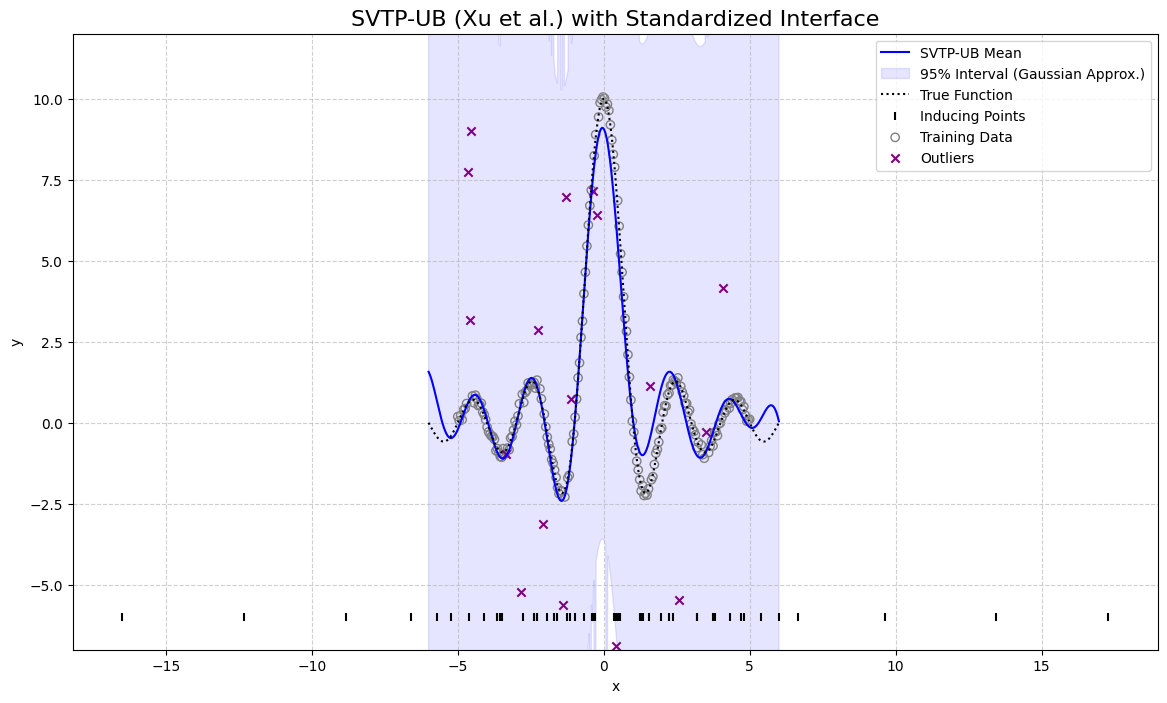

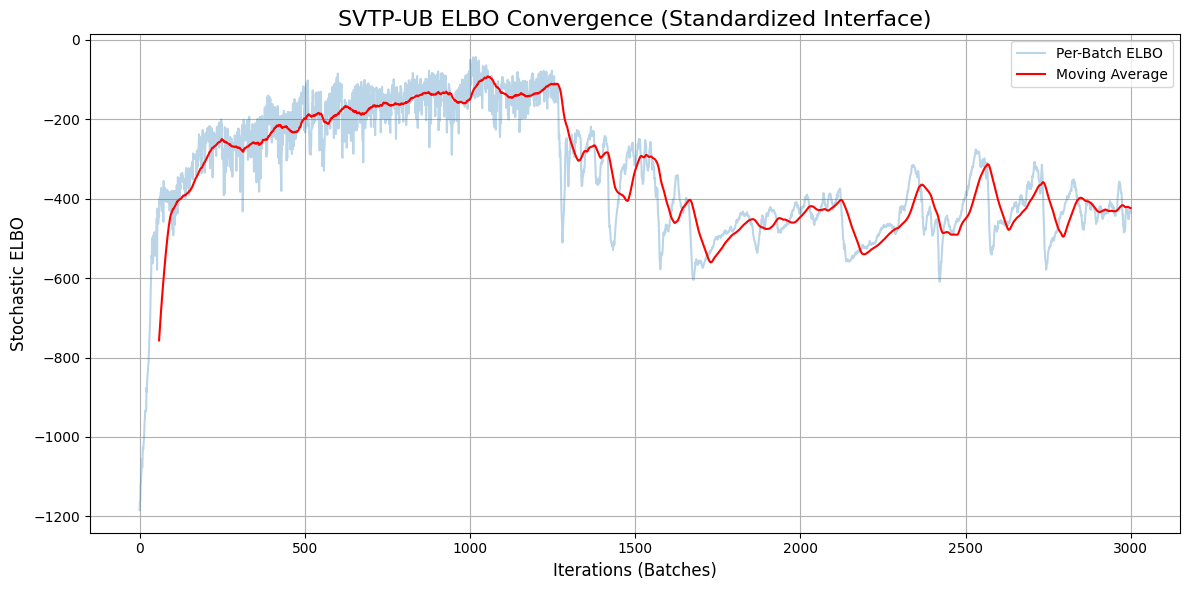

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import StudentT, Gamma
from torch.utils.data import DataLoader, TensorDataset
import math
import copy
import matplotlib.pyplot as plt
import tqdm
import pandas as pd

# Set default tensor type
torch.set_default_dtype(torch.float64)

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1.view(-1, X1.shape[-1]), X2.view(-1, X2.shape[-1]), p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale.pow(2))

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    (This is part of the original model's logic and is preserved.)
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    diff = x - mu.unsqueeze(-1)
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2

class SparseTPRTMiniBatch_Xu:
    """
    Implementation of Sparse Variational Student-t Process (SVTP) from Xu et al. (2021).
    This version is aligned with the structure of the other SparseTPRTMiniBatch classes.
    It directly optimizes a closed-form ELBO.
    THE INTERNAL CALCULATION LOGIC IS PRESERVED FROM THE ORIGINAL WORKING SCRIPT.
    """
    def __init__(self, X, y, M, nu_f=3.0, nu_e=3.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        self.X_full = X
        self.y_full = y.view(-1, 1)
        self.N, self.D = X.shape
        self.M = M

        # --- Trainable Parameters (Hyperparameters, Inducing Points, Variational Params) ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)
        
        # Hyperparameters (log-transformed for stability)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma, dtype=X.dtype)))
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0, dtype=X.dtype)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0, dtype=X.dtype)))

        # Variational parameters for q(u)
        self.mu_q = nn.Parameter(torch.zeros(self.M, dtype=X.dtype))
        self.S_chol_q = nn.Parameter(torch.eye(self.M, dtype=X.dtype))

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_f = torch.exp(self.log_nu_f_minus_2) + 2.0
        nu_q = nu_f + self.N
        nu_e = torch.exp(self.log_nu_e_minus_2) + 2.0
        
        return {
            "nu_f": nu_f, "nu_q": nu_q, "nu_e": nu_e,
            "likelihood_sigma": torch.exp(self.log_likelihood_sigma),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
        }

    # === CORE LOGIC METHODS (PRESERVED FROM ORIGINAL) ===
    def _sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X_full.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    def _kl_divergence(self, K_mm, S_q, nu_prior, nu_q):
        K_mm_inv = torch.inverse(K_mm)
        l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
        tr_term = torch.trace(K_mm_inv @ S_q)
        mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
        l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
        sign_S, logdet_S = torch.linalg.slogdet(S_q)
        if sign_S.item() <= 0: return float('inf')
        sign_K, logdet_K = torch.linalg.slogdet(K_mm)
        if sign_K.item() <= 0: return float('inf')
        log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
        C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
        kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
        return kl_approx

    def _expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples=1):
        u_samples = self._sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def _calculate_elbo(self, X_batch, y_batch, num_samples=1):
        params = self._get_hyperparams()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X_full.device)
        K_mm = rbf_kernel(self.Z, self.Z, params['variance'], params['lengthscale']) + 1e-6 * torch.eye(self.M, device=self.X_full.device)
        K_nm = rbf_kernel(X_batch, self.Z, params['variance'], params['lengthscale'])
        K_mm_inv = torch.inverse(K_mm)

        kl = self._kl_divergence(K_mm, S_q, params['nu_f'], params['nu_q'])
        exp_log_lik = self._expected_log_likelihood(X_batch, y_batch.squeeze(), K_mm_inv, K_nm, params['nu_q'], params['nu_e'], params['likelihood_sigma'], num_samples)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def get_trainable_parameters(self):
        return [
            self.Z, self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f_minus_2, self.log_nu_e_minus_2,
            self.mu_q, self.S_chol_q
        ]

    def fit(self, epochs=100, batch_size=64, lr=0.01, num_samples_elbo=1):
        """Runs the full optimization algorithm using mini-batches."""
        optimizer = optim.Adam(self.get_trainable_parameters(), lr=lr)
        
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting joint optimization for {epochs} epochs with batch size {batch_size}...")
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for i, (X_batch, y_batch) in enumerate(dataloader):
                optimizer.zero_grad()
                elbo = self._calculate_elbo(X_batch, y_batch, num_samples=num_samples_elbo)
                loss = -elbo
                
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    optimizer.step()
                
                elbo_history.append(elbo.item())
            
            if epoch % 200 == 0:
                params = self._get_hyperparams()
                pbar.set_description(f"Epoch {epoch+1:4d} | -ELBO: {loss.item():.2f} | ν_f: {params['nu_f']:.2f} | ν_e: {params['nu_e']:.2f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test, num_samples=500):
        """Makes predictions for new data X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_mm = rbf_kernel(self.Z, self.Z, params['variance'], params['lengthscale']) + 1e-6 * torch.eye(self.M, device=self.X_full.device)
            K_star_m = rbf_kernel(X_test, self.Z, params['variance'], params['lengthscale'])
            K_star_star_diag = torch.diag(rbf_kernel(X_test, X_test, params['variance'], params['lengthscale']))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self._sample_q_u(params['nu_q'], num_samples=num_samples)
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            scale_factor = (params['nu_f'] + beta - 2) / (params['nu_f'] + self.M - 2)
            
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            var_likelihood = (params['likelihood_sigma']**2 * params['nu_e']) / (params['nu_e'] - 2)
            var_pred = var_f_total + var_likelihood
            
            pred_nu = torch.tensor(float('inf'), device=self.X_full.device)
            return mu_pred.unsqueeze(1), var_pred.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # --- 1. Generate and Standardize Data ---
    N = 200; M = 50
    X_train_orig = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train_orig = f_true(X_train_orig).squeeze() + torch.randn(N) * 0.1
    outlier_indices = torch.randperm(N)[:N//10]
    y_train_orig[outlier_indices] += torch.randn(len(outlier_indices)) * 5

    x_mean, x_std = X_train_orig.mean(), X_train_orig.std()
    y_mean, y_std = y_train_orig.mean(), y_train_orig.std()
    X_train_std = (X_train_orig - x_mean) / x_std
    y_train_std = (y_train_orig - y_mean) / y_std

    # --- 2. Setup and Train Model with Standardized Interface ---
    model = SparseTPRTMiniBatch_Xu(
        X=X_train_std, y=y_train_std, M=M,
        nu_f=3.0, nu_e=3.0, kernel_lengthscale=1.0, 
        kernel_variance=1.0, likelihood_sigma=0.1
    )
    elbo_history = model.fit(epochs=3000, batch_size=1024, lr=0.01)

    # --- 3. Generate and Standardize Test Data ---
    X_test_orig = torch.linspace(-6, 6, 300).unsqueeze(1)
    X_test_std = (X_test_orig - x_mean) / x_std
    
    # --- 4. Get and Un-standardize Predictions ---
    pred_mean_std, pred_var_std, _ = model.predict(X_test_std)
    pred_mean = pred_mean_std * y_std + y_mean
    pred_std = torch.sqrt(pred_var_std) * y_std
    
    Z_unstd = model.Z.detach() * x_std + x_mean

    # --- 5. Plotting on Original Scale ---
    plt.figure(figsize=(14, 8))
    plt.title("SVTP-UB (Xu et al.) with Standardized Interface", fontsize=16)
    
    plt.plot(X_test_orig, pred_mean, color='blue', label="SVTP-UB Mean")
    lower = pred_mean.squeeze() - 1.96 * pred_std.squeeze()
    upper = pred_mean.squeeze() + 1.96 * pred_std.squeeze()
    plt.fill_between(X_test_orig.squeeze(), lower, upper, color='blue', alpha=0.1, label="95% Interval (Gaussian Approx.)")
    
    plt.plot(X_test_orig, f_true(X_test_orig), 'k', linestyle=':', label="True Function")
    plt.scatter(Z_unstd, torch.full_like(Z_unstd, -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    plt.scatter(X_train_orig[non_outliers], y_train_orig[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train_orig[outlier_indices], y_train_orig[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- 6. Plot ELBO History ---
    plt.figure(figsize=(12, 6))
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean()
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('SVTP-UB ELBO Convergence (Standardized Interface)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

🚀 Starting training with method: UB


Epoch 3000/3000, Final Batch ELBO: 772.53: 100%|██████████| 3000/3000 [00:16<00:00, 176.51it/s] 


✓ Training complete for method: UB
🚀 Starting training with method: MC


Epoch 3000/3000, Final Batch ELBO: 210.62: 100%|██████████| 3000/3000 [00:21<00:00, 140.38it/s] 


✓ Training complete for method: MC


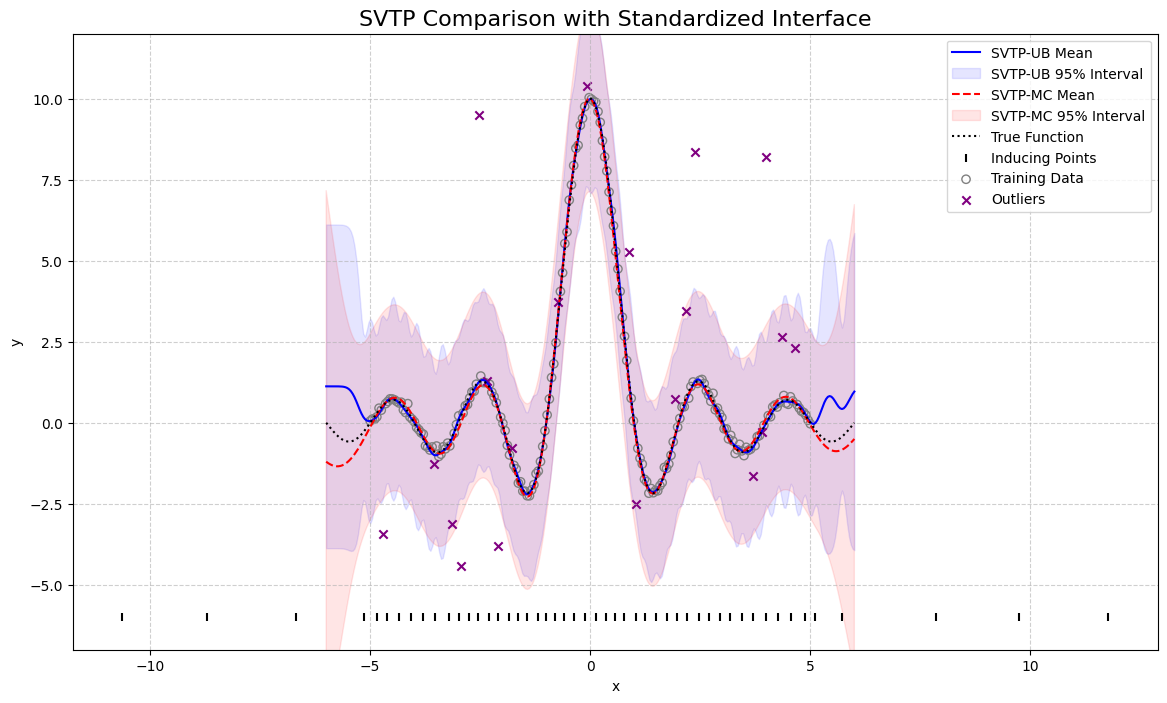

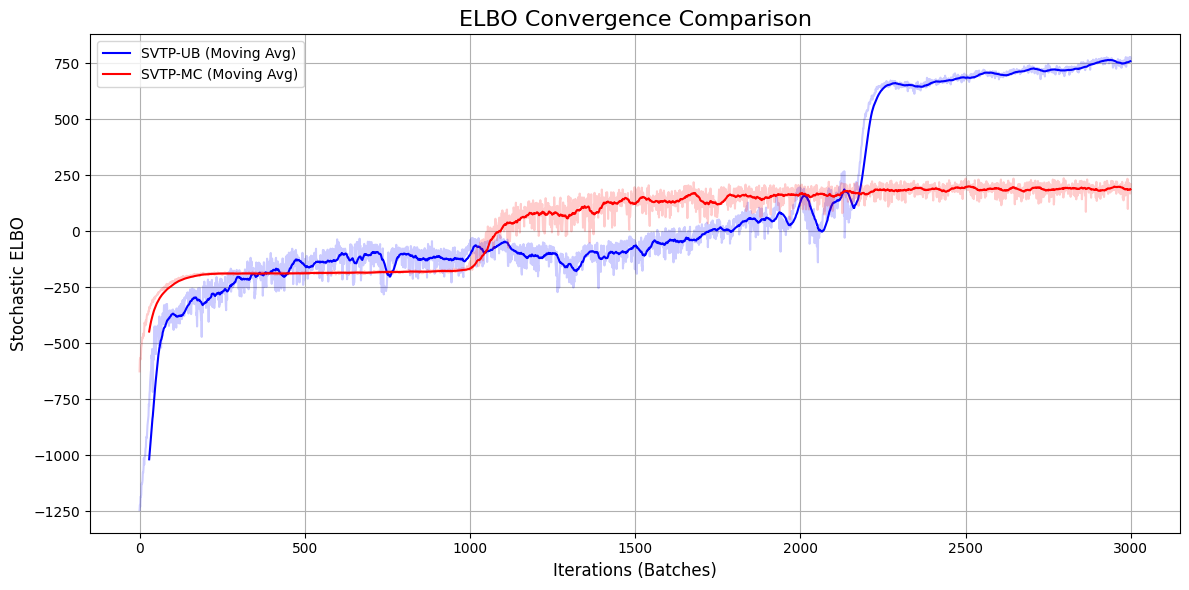

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import StudentT, Gamma
from torch.utils.data import DataLoader, TensorDataset
import math
import copy
import matplotlib.pyplot as plt
import tqdm
import pandas as pd

# Set default tensor type
torch.set_default_dtype(torch.float64)

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    # Ensure inputs are 2D
    d = X1.shape[-1]
    sqdist = torch.cdist(X1.view(-1, d), X2.view(-1, d), p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale.pow(2))

def logpdf_st(x, mu, K, nu):
    """
    Calculates the log-pdf of a multivariate Student-t distribution.
    (This is part of the original model's logic and is preserved.)
    """
    d = mu.shape[0]
    K_stable = K + 1e-6 * torch.eye(d, device=K.device)
    L = torch.linalg.cholesky(K_stable)
    log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))

    diff = x - mu.unsqueeze(-1)
    mahalanobis_dist = torch.sum(torch.square(torch.linalg.solve_triangular(L, diff, upper=False)), dim=0)

    term1 = torch.lgamma((nu + d) / 2) - torch.lgamma(nu / 2)
    term2 = -0.5 * log_det_K - (d / 2) * math.log((nu - 2) * math.pi)
    term3 = -((nu + d) / 2) * torch.log(1 + mahalanobis_dist / (nu - 2))

    return term3.squeeze() + term1 + term2

class SparseTPRTMiniBatch_Xu:
    """
    Implementation of Sparse Variational Student-t Process (SVTP) from Xu et al. (2021).
    This version is aligned with the structure of the other SparseTPRTMiniBatch classes
    and allows switching between UB and MC methods for the KL term.
    THE INTERNAL CALCULATION LOGIC IS PRESERVED FROM THE ORIGINAL WORKING SCRIPT.
    """
    def __init__(self, X, y, M, nu_f=3.0, nu_e=3.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        self.X_full = X
        self.y_full = y.view(-1, 1)
        self.N, self.D = X.shape
        self.M = M

        # --- Trainable Parameters ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)
        
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma, dtype=X.dtype)))
        self.log_nu_f_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_f - 2.0, dtype=X.dtype)))
        self.log_nu_e_minus_2 = nn.Parameter(torch.log(torch.tensor(nu_e - 2.0, dtype=X.dtype)))

        self.mu_q = nn.Parameter(torch.zeros(self.M, dtype=X.dtype))
        self.S_chol_q = nn.Parameter(torch.eye(self.M, dtype=X.dtype))

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        """Helper to get positive parameters from their transformed storage."""
        nu_f = torch.exp(self.log_nu_f_minus_2) + 2.0
        nu_q = nu_f + self.N
        nu_e = torch.exp(self.log_nu_e_minus_2) + 2.0
        
        return {
            "nu_f": nu_f, "nu_q": nu_q, "nu_e": nu_e,
            "likelihood_sigma": torch.exp(self.log_likelihood_sigma),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
        }

    # === CORE LOGIC METHODS (PRESERVED FROM ORIGINAL) ===
    def _sample_q_u(self, nu_q, num_samples=1):
        r_inv_dist = Gamma(nu_q / 2, 0.5)
        r_inv = r_inv_dist.sample((num_samples,))
        r = 1.0 / r_inv
        eps = torch.randn(self.M, num_samples, device=self.X_full.device)
        u_samples = self.mu_q.unsqueeze(1) + self.S_chol_q @ (eps * torch.sqrt(r).T)
        return u_samples

    def _kl_divergence(self, K_mm, S_q, nu_prior, nu_q, method='UB', num_samples_kl=10):
        """Calculates KL(q(u) || p(u)) using either Upper Bound (UB) or Monte Carlo (MC)."""
        if method == 'MC':
            u_samples = self._sample_q_u(nu_q, num_samples=num_samples_kl)
            log_q_u = logpdf_st(u_samples, self.mu_q, S_q, nu_q)
            log_p_u = logpdf_st(u_samples, torch.zeros(self.M, device=self.X_full.device), K_mm, nu_prior)
            return torch.mean(log_q_u - log_p_u)
        
        elif method == 'UB':
            K_mm_inv = torch.inverse(K_mm)
            l1 = torch.digamma((nu_q + self.M) / 2) - torch.digamma(nu_q / 2)
            tr_term = torch.trace(K_mm_inv @ S_q)
            mean_term = self.mu_q.T @ K_mm_inv @ self.mu_q
            l2_star = torch.log(1 + (tr_term + mean_term) / (nu_prior - 2))
            sign_S, logdet_S = torch.linalg.slogdet(S_q)
            if sign_S.item() <= 0: return float('inf')
            sign_K, logdet_K = torch.linalg.slogdet(K_mm)
            if sign_K.item() <= 0: return float('inf')
            log_nu_diff = torch.log(nu_prior - 2) - torch.log(nu_q - 2)
            C = 0.5 * (logdet_S - logdet_K + self.M * log_nu_diff)
            kl_approx = C - ((nu_q + self.M) / 2) * l1 + ((nu_prior + self.M) / 2) * l2_star
            return kl_approx
        else:
            raise ValueError("kl_method must be 'UB' or 'MC'")

    def _expected_log_likelihood(self, X_batch, y_batch, K_mm_inv, K_nm, nu_q, nu_lik, sigma_n, num_samples=1):
        u_samples = self._sample_q_u(nu_q, num_samples)
        f_est_samples = K_nm @ K_mm_inv @ u_samples
        dist = StudentT(df=nu_lik)
        log_p_y_given_f = dist.log_prob((y_batch.unsqueeze(1) - f_est_samples) / sigma_n) - torch.log(sigma_n)
        return torch.mean(torch.sum(log_p_y_given_f, dim=0))

    def _calculate_elbo(self, X_batch, y_batch, kl_method, num_samples_elbo, num_samples_kl):
        params = self._get_hyperparams()
        S_q = self.S_chol_q @ self.S_chol_q.T + 1e-6 * torch.eye(self.M, device=self.X_full.device)
        K_mm = rbf_kernel(self.Z, self.Z, params['variance'], params['lengthscale']) + 1e-6 * torch.eye(self.M, device=self.X_full.device)
        K_nm = rbf_kernel(X_batch, self.Z, params['variance'], params['lengthscale'])
        K_mm_inv = torch.inverse(K_mm)

        kl = self._kl_divergence(K_mm, S_q, params['nu_f'], params['nu_q'], method=kl_method, num_samples_kl=num_samples_kl)
        exp_log_lik = self._expected_log_likelihood(X_batch, y_batch.squeeze(), K_mm_inv, K_nm, params['nu_q'], params['nu_e'], params['likelihood_sigma'], num_samples_elbo)
        
        scale = self.N / X_batch.shape[0]
        return scale * exp_log_lik - kl

    def get_trainable_parameters(self):
        return [
            self.Z, self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f_minus_2, self.log_nu_e_minus_2,
            self.mu_q, self.S_chol_q
        ]

    def fit(self, epochs=100, batch_size=64, lr=0.01, kl_method='UB', num_samples_elbo=1, num_samples_kl=10):
        """Runs the full optimization algorithm using mini-batches."""
        optimizer = optim.Adam(self.get_trainable_parameters(), lr=lr)
        
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"🚀 Starting training with method: {kl_method}")
        pbar = tqdm.trange(epochs)
        for epoch in pbar:
            for i, (X_batch, y_batch) in enumerate(dataloader):
                optimizer.zero_grad()
                elbo = self._calculate_elbo(X_batch, y_batch, kl_method, num_samples_elbo, num_samples_kl)
                loss = -elbo
                
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    optimizer.step()
                
                elbo_history.append(elbo.item())
            
            pbar.set_description(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo.item():.2f}")
        
        print(f"✓ Training complete for method: {kl_method}")
        return elbo_history

    def predict(self, X_test, num_samples=500):
        """Makes predictions for new data X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_mm = rbf_kernel(self.Z, self.Z, params['variance'], params['lengthscale']) + 1e-6 * torch.eye(self.M, device=self.X_full.device)
            K_star_m = rbf_kernel(X_test, self.Z, params['variance'], params['lengthscale'])
            K_star_star_diag = torch.diag(rbf_kernel(X_test, X_test, params['variance'], params['lengthscale']))
            K_mm_inv = torch.inverse(K_mm)
            
            u_samples = self._sample_q_u(params['nu_q'], num_samples=num_samples)
            f_star_mean_samples = K_star_m @ K_mm_inv @ u_samples
            
            beta = torch.sum((u_samples.T @ K_mm_inv) * u_samples.T, dim=1)
            scale_factor = (params['nu_f'] + beta - 2) / (params['nu_f'] + self.M - 2)
            
            K_star_m_K_inv = K_star_m @ K_mm_inv
            var_f_cond_u_diag = K_star_star_diag - torch.sum(K_star_m_K_inv * K_star_m, dim=1)
            f_star_var_samples = var_f_cond_u_diag.clamp(min=1e-6).unsqueeze(1) * scale_factor.unsqueeze(0)
            
            mu_pred = torch.mean(f_star_mean_samples, dim=1)
            var_f_total = torch.mean(f_star_var_samples, dim=1) + torch.var(f_star_mean_samples, dim=1)
            var_likelihood = (params['likelihood_sigma']**2 * params['nu_e']) / (params['nu_e'] - 2)
            var_pred = var_f_total + var_likelihood
            
            pred_nu = torch.tensor(float('inf'), device=self.X_full.device)
            return mu_pred.unsqueeze(1), var_pred.unsqueeze(1), pred_nu

if __name__ == '__main__':
    # --- 1. Generate and Standardize Data ---
    N = 200; M = 50
    X_train_orig = torch.linspace(-5, 5, N).unsqueeze(1)
    def f_true(x): return torch.sinc(x) * 10
    y_train_orig = f_true(X_train_orig).squeeze() + torch.randn(N) * 0.1
    outlier_indices = torch.randperm(N)[:N//10]
    y_train_orig[outlier_indices] += torch.randn(len(outlier_indices)) * 5

    x_mean, x_std = X_train_orig.mean(), X_train_orig.std()
    y_mean, y_std = y_train_orig.mean(), y_train_orig.std()
    X_train_std = (X_train_orig - x_mean) / x_std
    y_train_std = (y_train_orig - y_mean) / y_std

    # --- 2. Setup and Train Models ---
    initial_model = SparseTPRTMiniBatch_Xu(X_train_std, y_train_std, M=M)

    # Train UB model
    model_ub = copy.deepcopy(initial_model)
    elbo_history_ub = model_ub.fit(epochs=3000, lr=0.01, kl_method='UB', batch_size=1024)

    # Train MC model
    model_mc = copy.deepcopy(initial_model)
    elbo_history_mc = model_mc.fit(epochs=3000, lr=0.01, kl_method='MC', batch_size=1024, num_samples_kl=10)

    # --- 3. Generate and Standardize Test Data ---
    X_test_orig = torch.linspace(-6, 6, 300).unsqueeze(1)
    X_test_std = (X_test_orig - x_mean) / x_std
    
    # --- 4. Get and Un-standardize Predictions ---
    mu_ub_std, var_ub_std, _ = model_ub.predict(X_test_std)
    mu_ub = mu_ub_std.squeeze() * y_std + y_mean
    std_ub = torch.sqrt(var_ub_std.squeeze()) * y_std
    
    mu_mc_std, var_mc_std, _ = model_mc.predict(X_test_std)
    mu_mc = mu_mc_std.squeeze() * y_std + y_mean
    std_mc = torch.sqrt(var_mc_std.squeeze()) * y_std

    Z_ub_unstd = model_ub.Z.detach() * x_std + x_mean

    # --- 5. Plotting on Original Scale ---
    plt.figure(figsize=(14, 8))
    plt.title("SVTP Comparison with Standardized Interface", fontsize=16)
    
    # Plot UB results
    plt.plot(X_test_orig, mu_ub, color='blue', label="SVTP-UB Mean")
    plt.fill_between(X_test_orig.squeeze(), mu_ub - 1.96*std_ub, mu_ub + 1.96*std_ub, color='blue', alpha=0.1, label="SVTP-UB 95% Interval")
    
    # Plot MC results
    plt.plot(X_test_orig, mu_mc, color='red', linestyle='--', label="SVTP-MC Mean")
    plt.fill_between(X_test_orig.squeeze(), mu_mc - 1.96*std_mc, mu_mc + 1.96*std_mc, color='red', alpha=0.1, label="SVTP-MC 95% Interval")
    
    # Plot other elements
    plt.plot(X_test_orig, f_true(X_test_orig), 'k', linestyle=':', label="True Function")
    plt.scatter(Z_ub_unstd, torch.full_like(Z_ub_unstd, -6), marker='|', color='black', label="Inducing Points")
    
    non_outliers = torch.ones(N, dtype=torch.bool); non_outliers[outlier_indices] = False
    plt.scatter(X_train_orig[non_outliers], y_train_orig[non_outliers], marker='o', facecolors='none', edgecolors='gray', label="Training Data")
    plt.scatter(X_train_orig[outlier_indices], y_train_orig[outlier_indices], marker='x', color='purple', label="Outliers")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.ylim(-7, 12); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- 6. Plot ELBO History Comparison ---
    plt.figure(figsize=(12, 6))
    plt.title('ELBO Convergence Comparison', fontsize=16)
    
    # UB ELBO
    elbo_series_ub = pd.Series(elbo_history_ub)
    elbo_moving_avg_ub = elbo_series_ub.rolling(window=len(elbo_history_ub) // 100).mean()
    plt.plot(elbo_history_ub, color='blue', alpha=0.2)
    plt.plot(elbo_moving_avg_ub, color='blue', label='SVTP-UB (Moving Avg)')

    # MC ELBO
    elbo_series_mc = pd.Series(elbo_history_mc)
    elbo_moving_avg_mc = elbo_series_mc.rolling(window=len(elbo_history_mc) // 100).mean()
    plt.plot(elbo_history_mc, color='red', alpha=0.2)
    plt.plot(elbo_moving_avg_mc, color='red', label='SVTP-MC (Moving Avg)')
    
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()